# German Credit Data Analysis

This notebook provides a comprehensive analysis of the German credit dataset including data exploration, cleaning, visualization, and statistical insights.

## 1. Import Required Libraries

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# Create plots folder
if not os.path.exists('plots'):
    os.makedirs('plots')


# Set display optionsplt.rcParams['figure.figsize'] = (12, 6)

# pd.set_option('display.max_columns', None)sns.set_style('whitegrid')
# pd.set_option('display.max_rows', 100)

## 2. Load the CSV File

In [67]:
# Load the dataset
df = pd.read_csv('german_credit_data.csv', index_col=0)
print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
df.head(10)

Dataset shape: (1000, 9)

First few rows:


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car
5,35,male,1,free,NaN,NaN,9055,36,education
6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment
7,35,male,3,rent,little,moderate,6948,36,car
8,61,male,1,own,rich,NaN,3059,12,radio/TV
9,28,male,3,own,little,moderate,5234,30,car


In [68]:
# Last few rows
print("Last few rows:")
df.tail(10)

Last few rows:


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
990,37,male,1,own,NaN,NaN,3565,12,education
991,34,male,1,own,moderate,NaN,1569,15,radio/TV
992,23,male,1,rent,NaN,little,1936,18,radio/TV
993,30,male,3,own,little,little,3959,36,furniture/equipment
994,50,male,2,own,NaN,NaN,2390,12,car
995,31,female,1,own,little,NaN,1736,12,furniture/equipment
996,40,male,3,own,little,little,3857,30,car
997,38,male,2,own,little,NaN,804,12,radio/TV
998,23,male,2,free,little,little,1845,45,radio/TV
999,27,male,2,own,moderate,moderate,4576,45,car


## 3. Explore Data Structure

In [69]:
# Dataset info
print("Dataset Information:")
print("="*50)
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 78.1+ KB


In [70]:
# Column names and data types
print("\nColumn Data Types:")
print("="*50)
print(df.dtypes)
print(f"\nTotal columns: {len(df.columns)}")
print(f"Total rows: {len(df)}")


Column Data Types:
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
dtype: object

Total columns: 9
Total rows: 1000


In [71]:
# Check for missing values
print("Missing Values Analysis:")
print("="*50)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_data[missing_data['Missing_Count'] > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values Analysis:
                            Column  Missing_Count  Missing_Percentage
Saving accounts    Saving accounts            183                18.3
Checking account  Checking account            394                39.4

Total missing values: 577


In [72]:
# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Duplicate rows: 0

Unique values per column:
Age: 53 unique values
Sex: 2 unique values
Job: 4 unique values
Housing: 3 unique values
Saving accounts: 4 unique values
Checking account: 3 unique values
Credit amount: 921 unique values
Duration: 33 unique values
Purpose: 8 unique values


## 4. Data Cleaning and Preprocessing

In [73]:
# Create a copy for cleaning
df_clean = df.copy()

# Handle missing values represented as 'NA'
print("Handling missing values...")
df_clean = df_clean.replace('NA', np.nan)

# Display missing values summary after conversion
print("\nMissing values after conversion:")
missing_summary = df_clean.isnull().sum()
print(missing_summary[missing_summary > 0])

# Fill missing values with mode for categorical columns
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col].fillna(df_clean[col].mode()[0] if len(df_clean[col].mode()) > 0 else 'Unknown', inplace=True)

print(f"\nTotal missing values after cleaning: {df_clean.isnull().sum().sum()}")

Handling missing values...

Missing values after conversion:
Saving accounts     183
Checking account    394
dtype: int64

Total missing values after cleaning: 0


In [53]:
# Display cleaned data sample
print("Cleaned dataset sample:")
df_clean.sample(10)

Cleaned dataset sample:


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
10,25,female,2,rent,little,moderate,1295,12,car
116,30,female,3,own,little,little,7174,42,radio/TV
582,26,female,2,rent,little,little,1388,9,furniture/equipment
574,27,male,1,own,little,moderate,1082,9,radio/TV
933,42,male,2,own,quite rich,little,522,12,radio/TV
879,36,male,2,own,little,little,6742,30,radio/TV
288,49,female,2,own,little,moderate,1092,12,radio/TV
593,20,female,1,rent,little,moderate,2718,24,car
616,27,male,3,free,little,moderate,9157,60,radio/TV
53,31,male,2,own,little,little,3378,18,car


## 5. Descriptive Statistics

In [54]:
# Summary statistics for numerical columns
print("Summary Statistics (Numerical Columns):")
print("="*80)
df_clean.describe().T

Summary Statistics (Numerical Columns):


,count,mean,std,min,25%,50%,75%,max
Age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
Job,1000.0,1.904,0.653614,0.0,2.0,2.0,2.00,3.0
Credit amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0


In [55]:
# Detailed statistics
print("\nDetailed Statistics:")
print("="*80)
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns

for col in numerical_cols:
    print(f"\n{col}:")
    print(f"  Mean: {df_clean[col].mean():.2f}")
    print(f"  Median: {df_clean[col].median():.2f}")
    print(f"  Std Dev: {df_clean[col].std():.2f}")
    print(f"  Min: {df_clean[col].min():.2f}")
    print(f"  Max: {df_clean[col].max():.2f}")
    print(f"  Q1 (25%): {df_clean[col].quantile(0.25):.2f}")
    print(f"  Q3 (75%): {df_clean[col].quantile(0.75):.2f}")


Detailed Statistics:

Age:
  Mean: 35.55
  Median: 33.00
  Std Dev: 11.38
  Min: 19.00
  Max: 75.00
  Q1 (25%): 27.00
  Q3 (75%): 42.00

Job:
  Mean: 1.90
  Median: 2.00
  Std Dev: 0.65
  Min: 0.00
  Max: 3.00
  Q1 (25%): 2.00
  Q3 (75%): 2.00

Credit amount:
  Mean: 3271.26
  Median: 2319.50
  Std Dev: 2822.74
  Min: 250.00
  Max: 18424.00
  Q1 (25%): 1365.50
  Q3 (75%): 3972.25

Duration:
  Mean: 20.90
  Median: 18.00
  Std Dev: 12.06
  Min: 4.00
  Max: 72.00
  Q1 (25%): 12.00
  Q3 (75%): 24.00


In [56]:
# Categorical columns summary
print("\nCategorical Columns Summary:")
print("="*80)
categorical_cols = df_clean.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df_clean[col].value_counts())
    print(f"Unique values: {df_clean[col].nunique()}")


Categorical Columns Summary:

Sex:
Sex
male      690
female    310
Name: count, dtype: int64
Unique values: 2

Housing:
Housing
own     713
rent    179
free    108
Name: count, dtype: int64
Unique values: 3

Saving accounts:
Saving accounts
little        786
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64
Unique values: 4

Checking account:
Checking account
little      668
moderate    269
rich         63
Name: count, dtype: int64
Unique values: 3

Purpose:
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64
Unique values: 8


## 6. Data Visualization

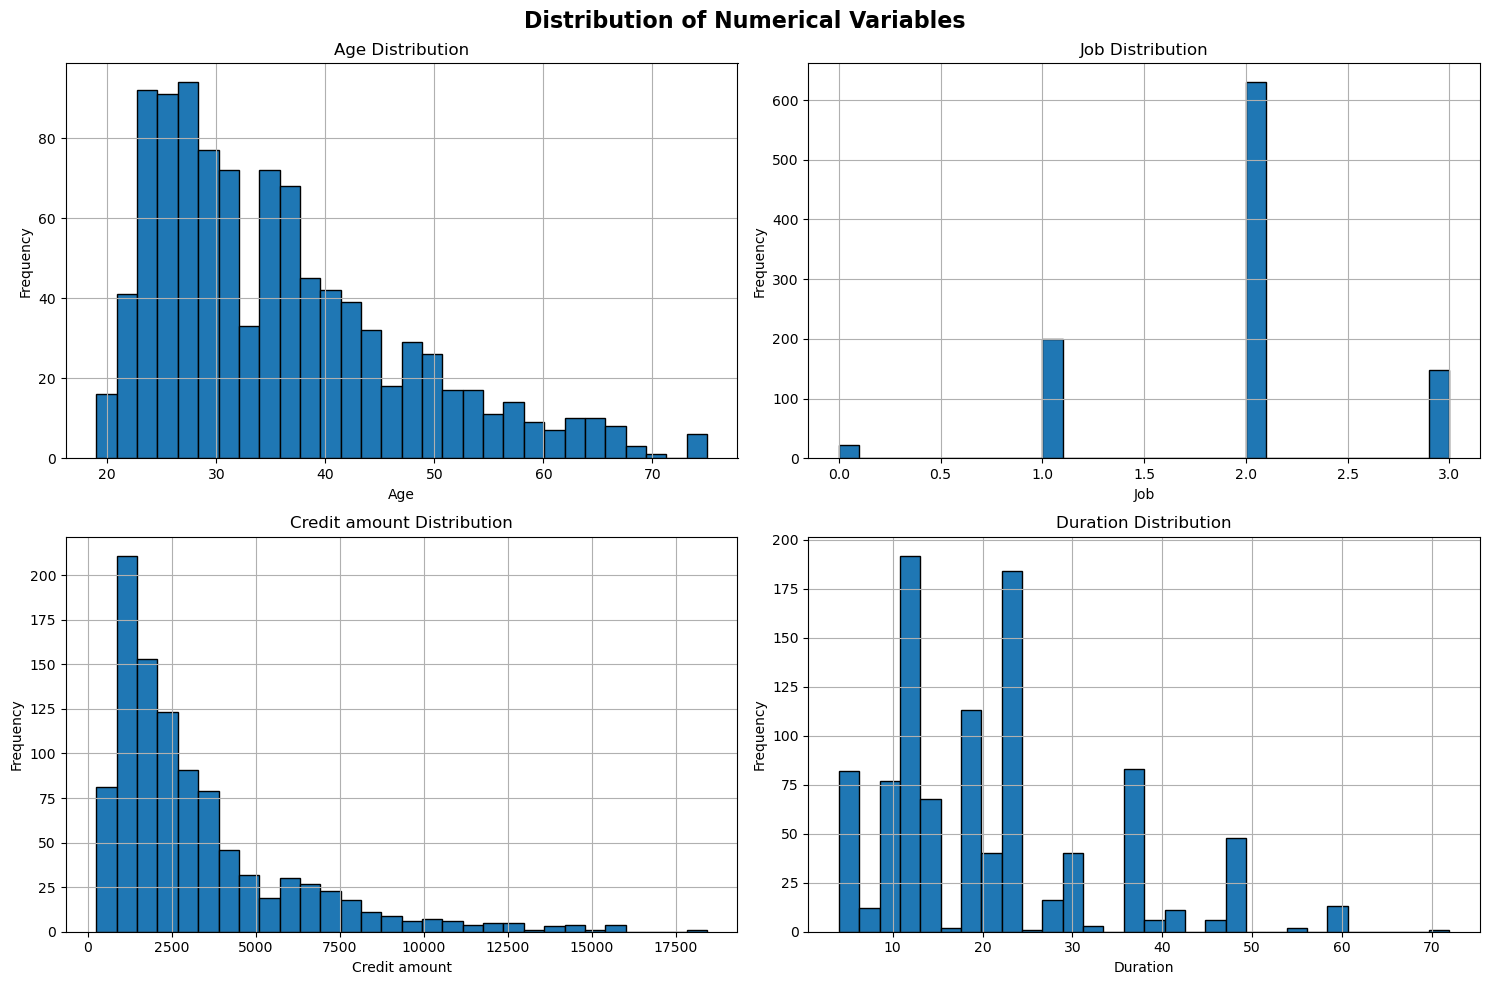

✅ Saved: plots/01_numerical_distributions.png


In [57]:
# Histograms for numerical columns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Numerical Variables', color='black', fontsize=16, fontweight='bold')

for idx, col in enumerate(numerical_cols):
    ax = axes[idx // 2, idx % 2]
    df_clean[col].hist(bins=30, ax=ax, edgecolor='black')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('plots/01_numerical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/01_numerical_distributions.png")

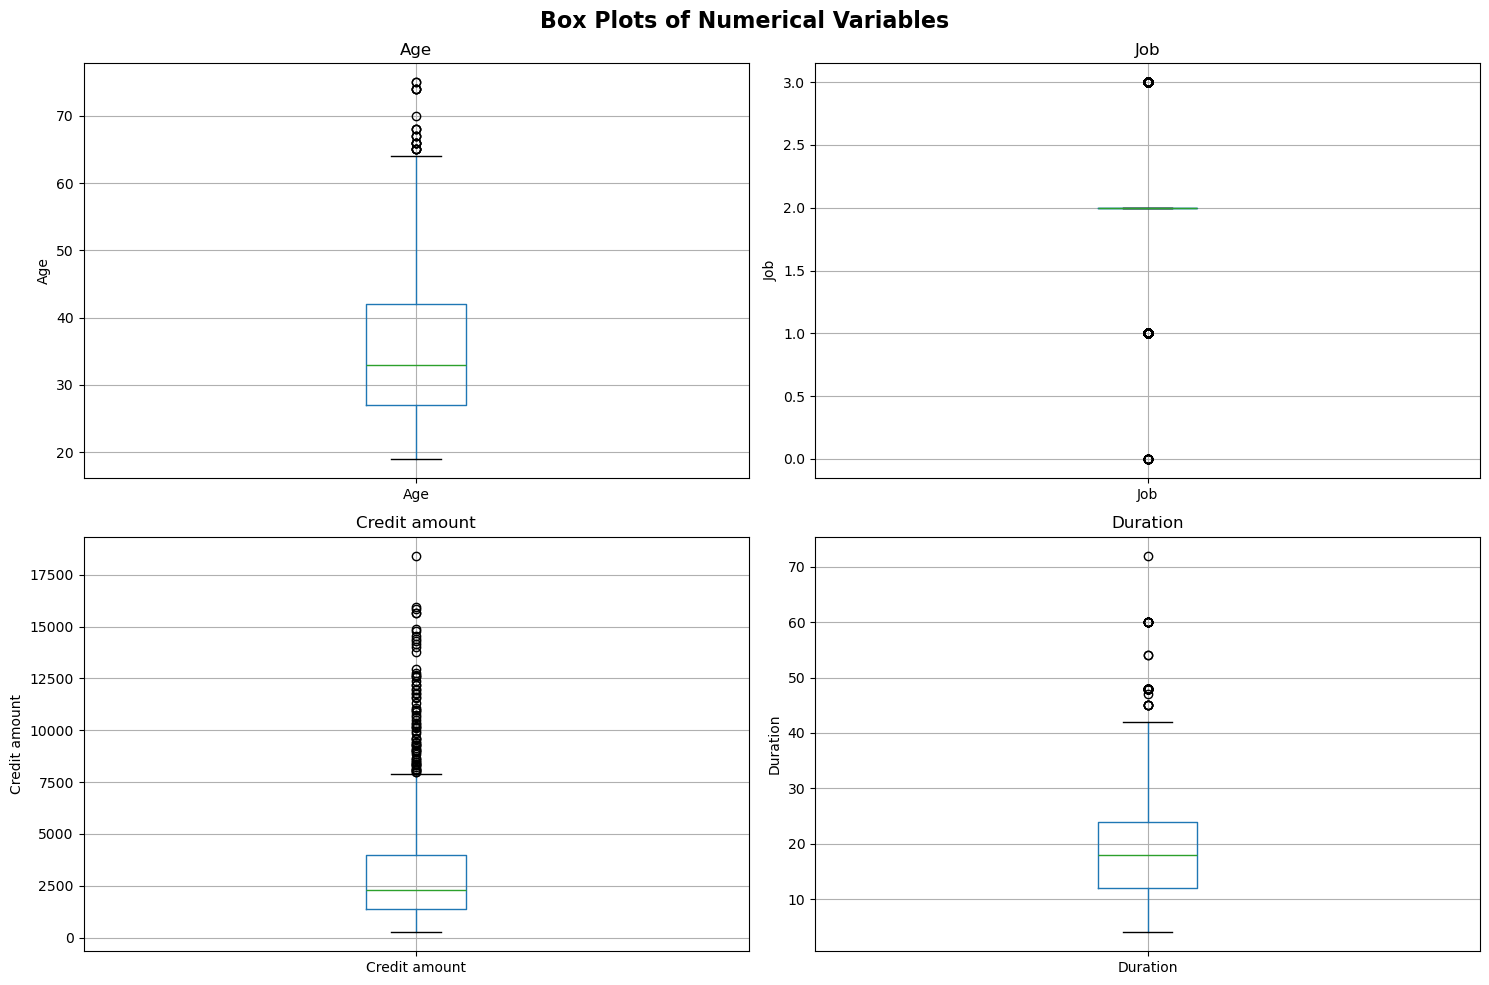

✅ Saved: plots/02_box_plots_numerical.png


In [58]:
# Box plots for numerical columns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Box Plots of Numerical Variables', color='black', fontsize=16, fontweight='bold')

for idx, col in enumerate(numerical_cols):
    ax = axes[idx // 2, idx % 2]
    df_clean.boxplot(column=col, ax=ax)
    ax.set_title(f'{col}')
    ax.set_ylabel(col)

plt.tight_layout()
plt.savefig('plots/02_box_plots_numerical.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/02_box_plots_numerical.png")

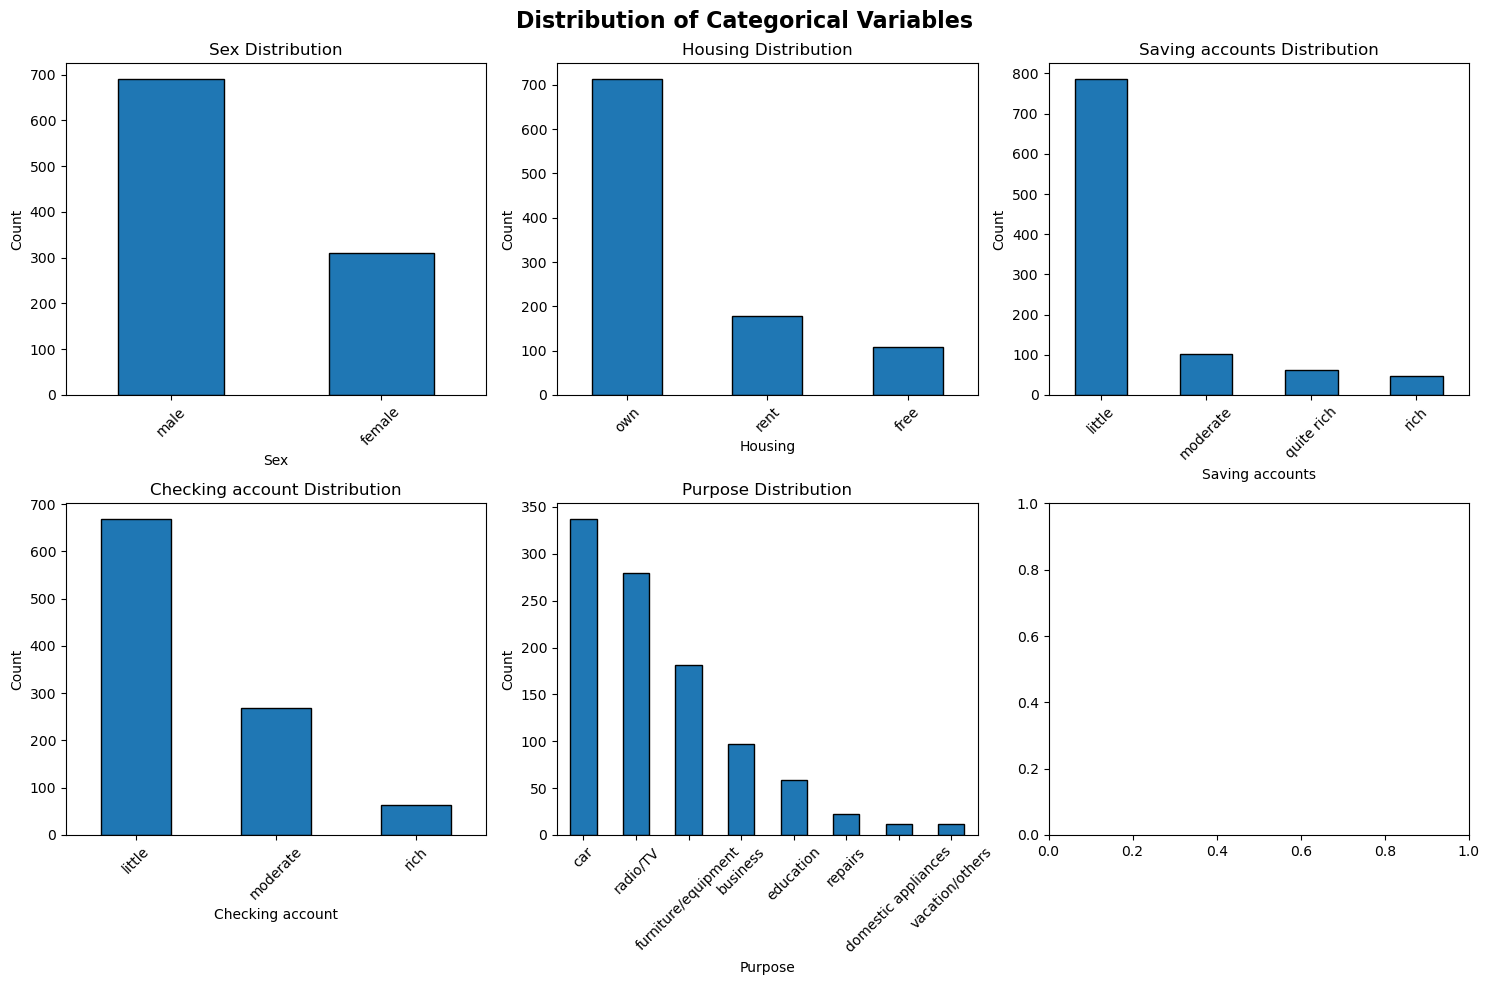

✅ Saved: plots/03_categorical_distributions.png


In [59]:
# Bar charts for categorical columns
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Categorical Variables', fontsize=16, fontweight='bold')

for idx, col in enumerate(categorical_cols):
    ax = axes[idx // 3, idx % 3]
    df_clean[col].value_counts().plot(kind='bar', ax=ax, edgecolor='black')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plots/03_categorical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/03_categorical_distributions.png")

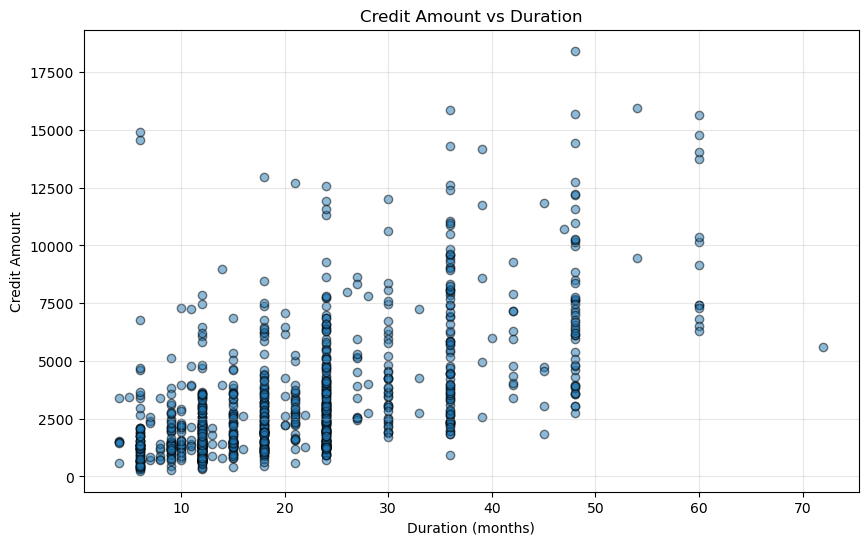

✅ Saved: plots/04_credit_vs_duration.png


In [60]:
# Credit amount vs Duration scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Duration'], df_clean['Credit amount'], alpha=0.5, edgecolor='black')
plt.xlabel('Duration (months)')
plt.ylabel('Credit Amount')
plt.title('Credit Amount vs Duration')
plt.grid(True, alpha=0.3)
plt.savefig('plots/04_credit_vs_duration.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/04_credit_vs_duration.png")

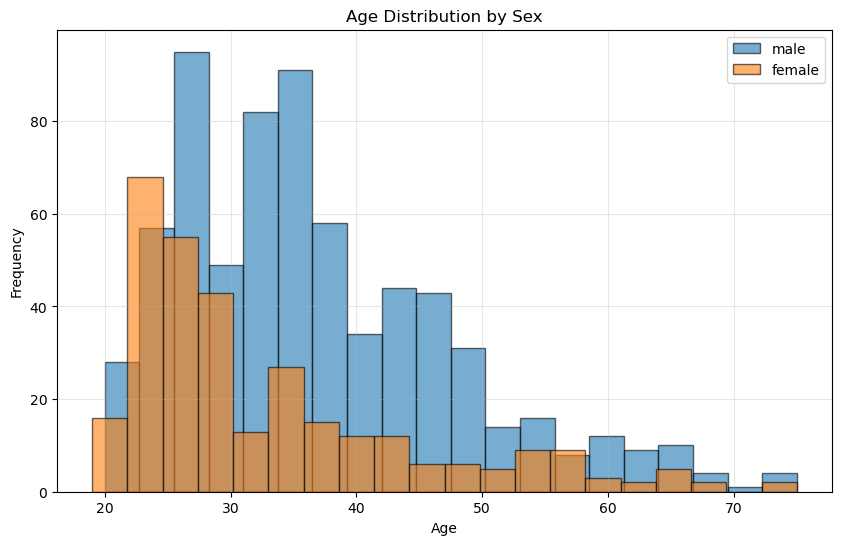

✅ Saved: plots/05_age_distribution_by_sex.png


In [61]:
# Age distribution by Sex
plt.figure(figsize=(10, 6))
for sex in df_clean['Sex'].unique():
    df_clean[df_clean['Sex'] == sex]['Age'].hist(bins=20, alpha=0.6, label=sex, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution by Sex')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plots/05_age_distribution_by_sex.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/05_age_distribution_by_sex.png")

## 7. Correlation Analysis

In [62]:
# Calculate correlation matrix for numerical columns
correlation_matrix = df_clean[numerical_cols].corr()
print("Correlation Matrix:")
print("="*80)
print(correlation_matrix)

Correlation Matrix:
                    Age       Job  Credit amount  Duration
Age            1.000000  0.015673       0.032716 -0.036136
Job            0.015673  1.000000       0.285385  0.210910
Credit amount  0.032716  0.285385       1.000000  0.624984
Duration      -0.036136  0.210910       0.624984  1.000000


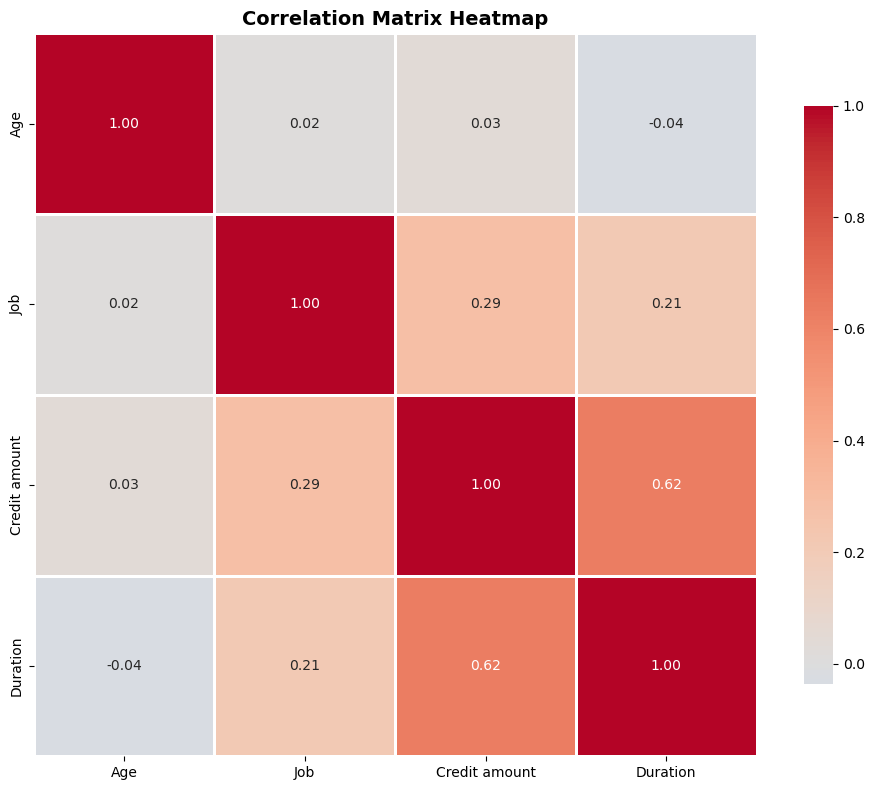

✅ Saved: plots/06_correlation_heatmap.png


In [63]:
# Visualize correlation matrix as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/06_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/06_correlation_heatmap.png")

In [64]:
# Find strong correlations
print("\nStrong Correlations (|correlation| > 0.5):")
print("="*80)

strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.5:
            strong_corr.append({
                'Variable 1': correlation_matrix.columns[i],
                'Variable 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if strong_corr:
    strong_corr_df = pd.DataFrame(strong_corr)
    print(strong_corr_df.to_string(index=False))
else:
    print("No strong correlations found (|correlation| > 0.5)")


Strong Correlations (|correlation| > 0.5):
   Variable 1 Variable 2  Correlation
Credit amount   Duration     0.624984


## Summary Insights

In [65]:
print("\n" + "="*80)
print("KEY INSIGHTS FROM GERMAN CREDIT DATA ANALYSIS")
print("="*80)

print(f"\n1. DATASET OVERVIEW:")
print(f"   - Total Records: {len(df_clean):,}")
print(f"   - Total Features: {len(df_clean.columns)}")
print(f"   - Missing Values: {df_clean.isnull().sum().sum()} (after cleaning)")

print(f"\n2. AGE DEMOGRAPHICS:")
print(f"   - Average Age: {df_clean['Age'].mean():.1f} years")
print(f"   - Age Range: {df_clean['Age'].min()}-{df_clean['Age'].max()} years")
print(f"   - Most Common Age Group: {df_clean['Age'].mode()[0]} years")

print(f"\n3. CREDIT INFORMATION:")
print(f"   - Average Credit Amount: ${df_clean['Credit amount'].mean():,.2f}")
print(f"   - Credit Amount Range: ${df_clean['Credit amount'].min():,} - ${df_clean['Credit amount'].max():,}")
print(f"   - Average Duration: {df_clean['Duration'].mean():.1f} months")
print(f"   - Most Common Purpose: {df_clean['Purpose'].mode()[0]}")

print(f"\n4. DEMOGRAPHIC DISTRIBUTION:")
print(f"   - Gender: {(df_clean['Sex'] == 'male').sum()} males, {(df_clean['Sex'] == 'female').sum()} females")
print(f"   - Housing Status Distribution:")
print(f"     {df_clean['Housing'].value_counts().to_dict()}")

print(f"\n5. FINANCIAL STATUS:")
print(f"   - Saving Accounts Distribution:")
print(f"     {df_clean['Saving accounts'].value_counts().to_dict()}")
print(f"   - Checking Account Distribution:")
print(f"     {df_clean['Checking account'].value_counts().to_dict()}")

print("\n" + "="*80)


KEY INSIGHTS FROM GERMAN CREDIT DATA ANALYSIS

1. DATASET OVERVIEW:
   - Total Records: 1,000
   - Total Features: 9
   - Missing Values: 0 (after cleaning)

2. AGE DEMOGRAPHICS:
   - Average Age: 35.5 years
   - Age Range: 19-75 years
   - Most Common Age Group: 27 years

3. CREDIT INFORMATION:
   - Average Credit Amount: $3,271.26
   - Credit Amount Range: $250 - $18,424
   - Average Duration: 20.9 months
   - Most Common Purpose: car

4. DEMOGRAPHIC DISTRIBUTION:
   - Gender: 690 males, 310 females
   - Housing Status Distribution:
     {'own': 713, 'rent': 179, 'free': 108}

5. FINANCIAL STATUS:
   - Saving Accounts Distribution:
     {'little': 786, 'moderate': 103, 'quite rich': 63, 'rich': 48}
   - Checking Account Distribution:
     {'little': 668, 'moderate': 269, 'rich': 63}

